# 03. The VAE and the (cos θ, sin θ) tilt representation

The model this repo is built around is **`factored_clean_noaug`**: a VAE whose latent is split into
a small **physical** part (the lander's x, y, tilt) and a **scene latent** (the terrain). This notebook
states what that model is and why tilt is represented as (cos θ, sin θ) rather than a raw angle. Whether
the latent is *actually* disentangled is examined in the report (`vae_report.pdf`); here the goal is just to
introduce the model and show it reconstructs.

The weights ship with the repo, so nothing trains here: the cached checkpoint is loaded and used.

## 1. Why tilt is (cos θ, sin θ), not a raw angle

An angle lives on a circle: +179° and −179° are 2° apart, but their raw difference is 358°. Training a
network to predict a raw angle with a mean-squared error therefore punishes a nearly-correct prediction
enormously whenever the truth sits near the ±180° seam, and the gradient points the wrong way. Encoding
tilt as the point **(cos θ, sin θ)** on the unit circle removes the seam: distance on the circle is always
the true angular distance. The plot below shows the naive error blowing up at the seam while the circular
distance stays bounded.

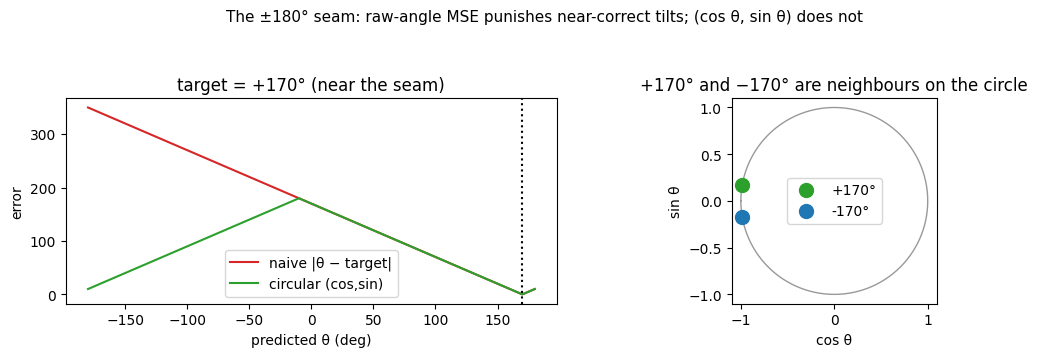

In [1]:
import numpy as np, matplotlib.pyplot as plt
th = np.linspace(-180, 180, 361)
target = 170.0
naive = np.abs(th - target)                          # raw-angle |error|
circular = np.abs((th - target + 180) % 360 - 180)   # what (cos,sin) distance gives
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(th, naive, label='naive |θ − target|', color='#d62728')
ax[0].plot(th, circular, label='circular (cos,sin)', color='#2ca02c')
ax[0].axvline(target, ls=':', color='k'); ax[0].set_xlabel('predicted θ (deg)')
ax[0].set_ylabel('error'); ax[0].set_title('target = +170° (near the seam)'); ax[0].legend()
t = np.radians(th); ax[1].plot(np.cos(t), np.sin(t), color='#999', lw=1)
for a, c in [(170, '#2ca02c'), (-170, '#1f77b4')]:
    ax[1].plot(np.cos(np.radians(a)), np.sin(np.radians(a)), 'o', color=c, ms=10, label=f'{a:+d}°')
ax[1].set_aspect('equal'); ax[1].set_title('+170° and −170° are neighbours on the circle')
ax[1].legend(); ax[1].set_xlabel('cos θ'); ax[1].set_ylabel('sin θ')
fig.suptitle('The ±180° seam: raw-angle MSE punishes near-correct tilts; (cos θ, sin θ) does not', fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.92]); plt.show()

## 2. The factored architecture, separate "what moves" from "what is fixed"

The one structural idea: **the scene/scene-latent encoder is fed a lander-erased image.**

- Segment the lander (purple mask), erase it (fill with background) to get a **scene-only** image.
- The **scene latent** dims `z[4:]` are encoded from that scene-only image, so they *cannot* contain the
  lander's pose; they hold only the terrain.
- The **lander is drawn from named physical dims**: `z0 = x`, `z1 = y` (injected from the state /
  controlled), `z2:4 = (cos θ, sin θ)` (from the crop tilt-branch).
- The decoder composes scene (from scene latent) and lander (from physical) into the full frame.

Moving the lander (physical dims) therefore cannot conflict with a scene latent, which is what
removes the far-position haze the earlier non-factored model suffered. The lander erasure is clean:

![scene only](figures/factored/scene_only_sanity.png)

## 3. Reconstruction, the shipped model on real test frames

Load `factored_clean_noaug` (cached) and reconstruct a seeded-random sample of fully-visible **test**
frames: inject each frame's true (x, y, θ) into the physical dims, encode its scene-only image into the
scene latent, and decode.

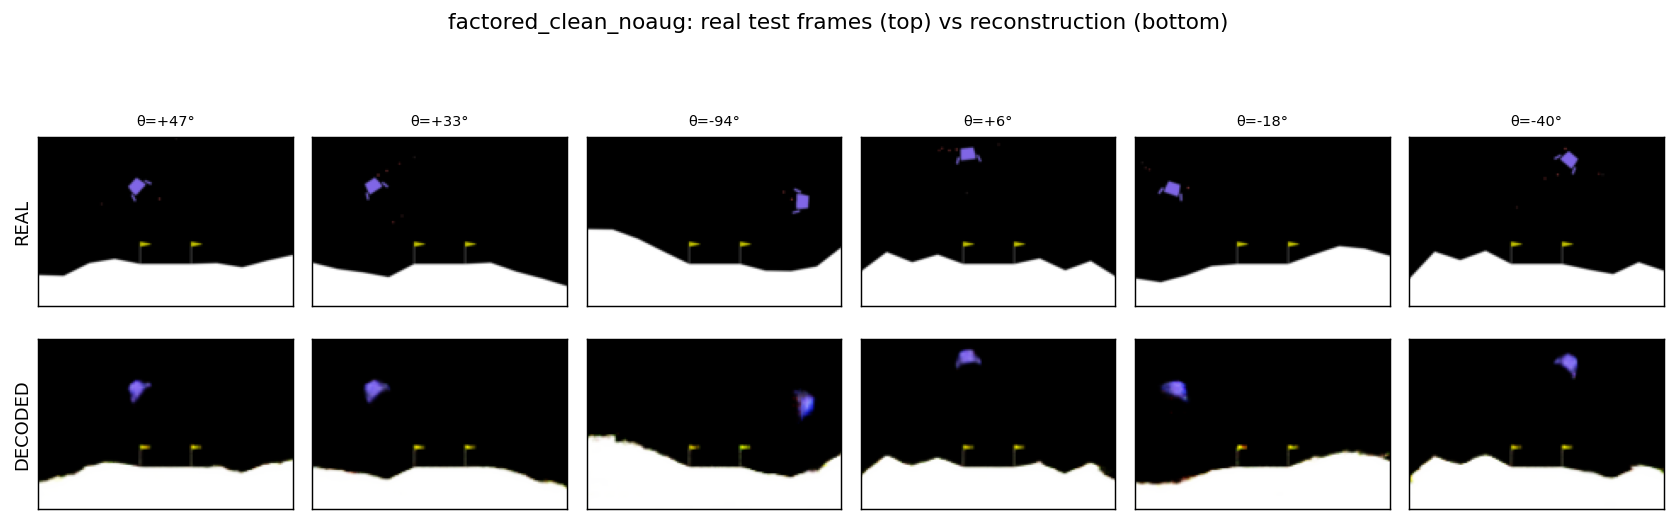

In [2]:
import sys, numpy as np, torch, matplotlib.pyplot as plt
sys.path.insert(0, '.')
import config, factored_data
import train_clean_vae as TC
from zlander_recon_fig import load, build_z
sys.path.insert(0, config.BASELINE_SRC)
from piwm_model.data import lander_fully_visible
config.set_seed()
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
m = load('factored_clean_noaug_best', dev)

teI, teC, teS, *_ = TC.preload(config.TEST_DIR, 40)
vis = [k for k in range(len(teI)) if lander_fully_visible(teI[k].permute(1, 2, 0).numpy())]
rng = np.random.default_rng(config.SEED)
idx = rng.choice(vis, size=6, replace=False)

fr = teI[idx].to(dev).float() / 255.; cr = teC[idx].to(dev).float() / 255.; stb = teS[idx]
sc = torch.stack([factored_data.scene_only(fr[k].cpu())[0] for k in range(len(idx))]).to(dev)
with torch.no_grad():
    z = build_z(m, sc, cr, stb, frame=fr)   # x,y READ from the image (read_xy), not the state
    rec = m['vae'].decode(z).clamp(0, 1).cpu()

fig, ax = plt.subplots(2, 6, figsize=(13, 4.4))
for a in ax.flat:
    a.set_xticks([]); a.set_yticks([])
for j in range(6):
    ax[0, j].imshow(fr[j].cpu().permute(1, 2, 0).numpy())
    ax[0, j].set_title(f"θ={np.degrees(float(stb[j, config.TH])):+.0f}°", fontsize=8)
    ax[1, j].imshow(rec[j].permute(1, 2, 0).numpy())
ax[0, 0].set_ylabel('REAL', fontsize=10); ax[1, 0].set_ylabel('DECODED', fontsize=10)
fig.suptitle('factored_clean_noaug: real test frames (top) vs reconstruction (bottom)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
# helper modules force the Agg backend, so save + embed (backend-independent) instead of plt.show()
import os
os.makedirs('figures/vae', exist_ok=True)
fig.savefig('figures/vae/factored_recon.png', dpi=130, bbox_inches='tight'); plt.close(fig)
from IPython.display import Image
Image('figures/vae/factored_recon.png')

**What to read here.** Position and terrain track the real frame: the lander appears in the right
place over the right ground. Some **fine lander detail** (the exact shape and legs) is not fully recovered at
this small ~90-pixel size, a known limitation discussed in the report (`vae_report.pdf`). The terrain comes
from the scene latent, so it is reconstructed rather than collapsed to a single canonical hill.

## 4. How the VAE was trained

The shipped weights are the end of a **three-stage, warm-started** procedure; each stage initializes from
the previous one and holds out the same episodes for validation (by episode, so no stage selects on data a
later stage trains on). The test split is never used for selection.

**Steps.**
1. **Tilt branch**, a small CNN reads (cos θ, sin θ) from a centered lander crop, supervised on the true angle.
2. **Position equivariance + concentration**, warm-start from (1); a per-axis swap-equivariance objective so
   dialing z[0:2] moves the lander in x and y, plus a concentration term to keep the lander compact.
3. **Factored scene-only fine-tune** (the shipped model), warm-start from (2); the scene latent z[4:] is encoded
   from the lander-**erased** image so it cannot carry pose, x and y are injected into z[0:2] from the state,
   and a θ-swap-equivariance term sharpens the tilt dial.

**Loss (stage 3, the shipped model):**

> L = recon + 1e-4·KL(scene latent z[4:]) + 1.0·θ_state + w_eq·position_swap + 1.0·θ_swap_equiv

- **recon** = region-weighted MSE (lander up-weighted ×25) + 1.0·edge(gradient) + 0.5·SSIM
- **KL** on the scene latent dims z[4:] only (encoded from the scene-only image)
- **θ_state** = MSE on (cos θ, sin θ), never raw-angle MSE (§1)
- **position_swap** = per-axis swap-equivariance on z[0:2] (controllability), ramped in over 8 epochs
- **θ_swap_equiv** = frozen-branch read-back of a commanded tilt, ramped in over 8 epochs
- x and y are **injected** into z[0:2] from the state (set, not learned by a loss term)

**Parameters** (recorded in `checkpoints/factored_clean_noaug_best.json`):

| parameter | value | parameter | value |
|---|---|---|---|
| latent dim | 32 | optimizer | Adam |
| learning rate | 1e-3 | grad clip | 0.3 |
| batch size | 32 | KL weight | 1e-4 |
| epochs | 70 (early-stopped @ 19) | lander recon weight | 25 |
| min epochs / patience | 20 / 8 | edge / SSIM weight | 1.0 / 0.5 |
| val fraction (by episode) | 0.15 | position-equiv weight | 2e-4 |
| train episodes | 345 | θ-equiv weight | 1.0 |
| seed | 0 | augmentation | none |

Early-stopped at epoch 19 at validation reconstruction MSE **0.0048**. The dataset is the fully-visible
Lunar Lander frames (see the data section of the README).

## Reproduce

The checkpoint `checkpoints/factored_clean_noaug_best.pt` ships with the repo, so this notebook loads cached
weights and trains nothing. The parameters above are read straight from the checkpoint's manifest
(`checkpoints/factored_clean_noaug_best.json`).

To **retrain the whole three-stage chain from scratch and verify it** (with `PIWM_DATA_ROOT` set to the
shared data), run `bash reproduce.sh`: it trains stages 1-3 and then calls `verify.py` to check the result
against the shipped weights (bit-identical on the same GPU, metrics within tolerance otherwise). Full
procedure, commands, and data decisions are in `TRAINING.md`.